Dataset loaded successfully!

   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor Sleep          Urban  
2              Poor Sleep          Urban  
3                     NaN         

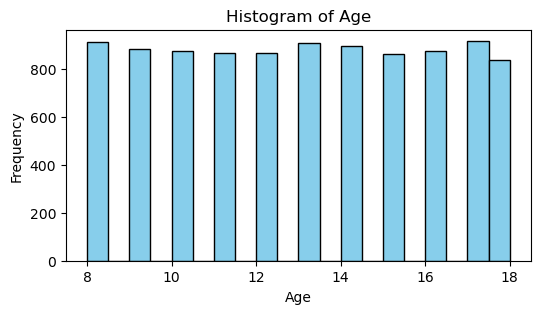

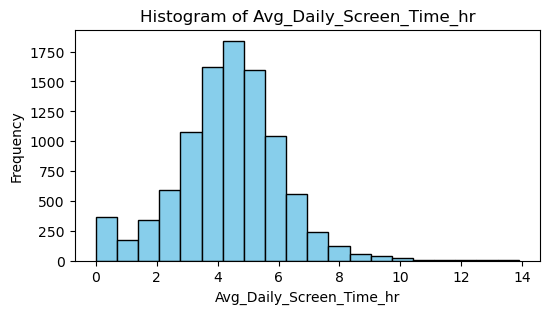

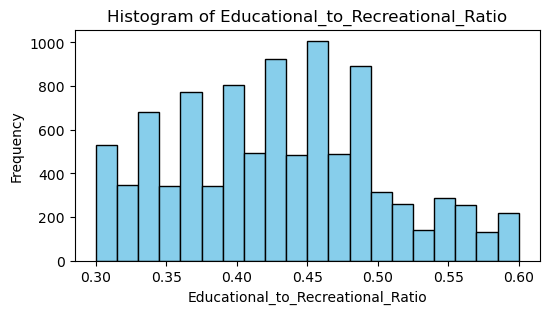


Correlation Matrix:
                                         Age  Avg_Daily_Screen_Time_hr  \
Age                                1.000000                  0.118328   
Avg_Daily_Screen_Time_hr           0.118328                  1.000000   
Educational_to_Recreational_Ratio -0.488617                 -0.087552   

                                   Educational_to_Recreational_Ratio  
Age                                                        -0.488617  
Avg_Daily_Screen_Time_hr                                   -0.087552  
Educational_to_Recreational_Ratio                           1.000000   



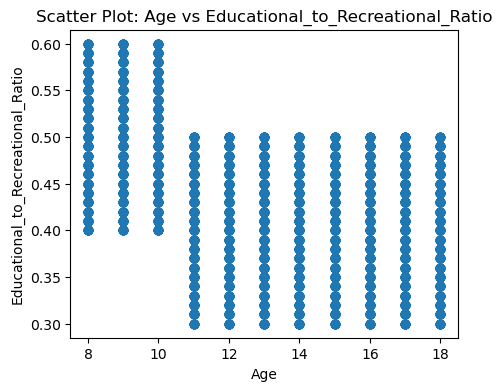

=== TASK 2: Distribution Analysis ===


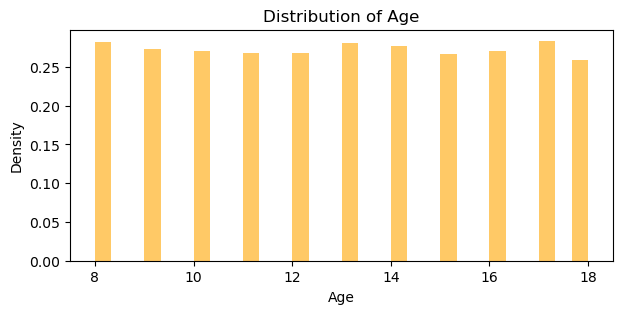

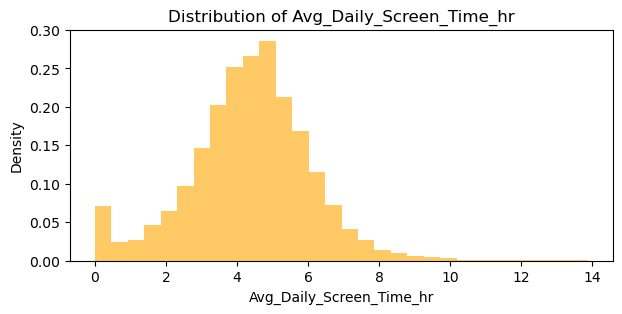

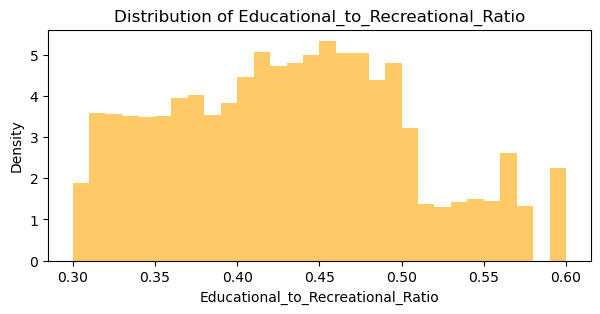

=== TASK 3: Screen Time to Health Impact ===
   Age  ScreenHours Age_Group Health_Impact
0   14         3.99     13-18      Moderate
1   11         4.61      6-12          High
2   18         3.73     13-18      Moderate
3   15         1.21     13-18           Low
4   12         5.89      6-12     Very High 

Average Screen Hours by Age Group:
 Age_Group
0-2           NaN
3-5           NaN
6-12     4.161296
13-18    4.511955
19+           NaN
Name: ScreenHours, dtype: float64 

Health Impact Distribution:
 Health_Impact
High         4642
Moderate     2350
Very High    2079
Low           641
Name: count, dtype: int64 



C:\Users\HP\AppData\Local\Temp\ipykernel_7428\3032933915.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_screen = df.groupby("Age_Group")["ScreenHours"].mean()


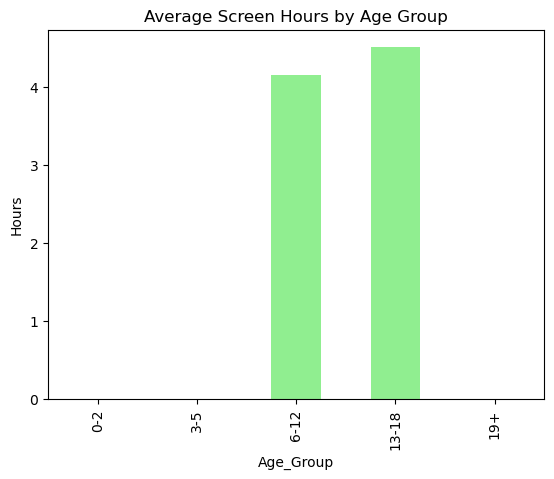

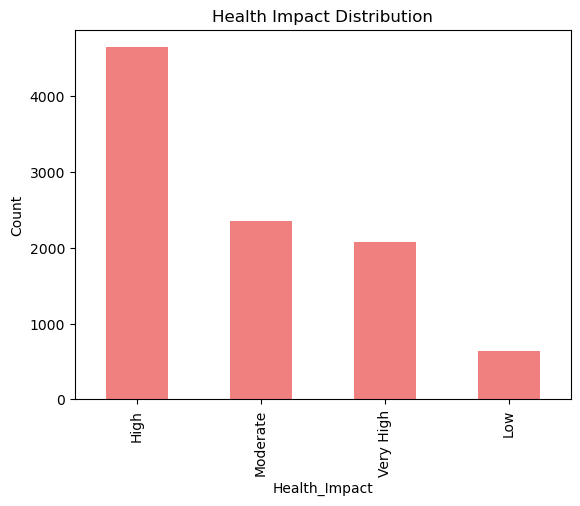

=== TASK 4: Recommendation System ===
Example Recommendations:

{'Age Group': '3-5', 'Gender': 'Male', 'Screen Hours': 2, 'Health Impact': 'High', 'Recommendation': 'Too much screen time — reduce at least by 1-2 hours daily.'} 

{'Age Group': '6-12', 'Gender': 'Female', 'Screen Hours': 4, 'Health Impact': 'High', 'Recommendation': 'Too much screen time — reduce at least by 1-2 hours daily.'} 

{'Age Group': '13-18', 'Gender': 'Male', 'Screen Hours': 5, 'Health Impact': 'High', 'Recommendation': 'Too much screen time — reduce at least by 1-2 hours daily.'} 

{'Age Group': '19+', 'Gender': 'Female', 'Screen Hours': 7, 'Health Impact': 'High', 'Recommendation': 'Too much screen time — reduce at least by 1-2 hours daily.'} 



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- Step 0: Load Dataset ----------
df = pd.read_csv("Indian_Kids_Screen_Time.csv")
print("Dataset loaded successfully!\n")
print(df.head(), "\n")

# Auto-detect columns
age_col = next((c for c in df.columns if "age" in c.lower()), None)
screen_col = next((c for c in df.columns if "screen" in c.lower() or "time" in c.lower()), None)
gender_col = next((c for c in df.columns if "gender" in c.lower()), None)

print(f"Detected columns: Age = {age_col}, Screen Time = {screen_col}, Gender = {gender_col}\n")

# ---------- TASK 1: Univariate & Bivariate Analysis ----------
print("=== TASK 1: Univariate & Bivariate Analysis ===")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNumeric Summary:\n", df[numeric_cols].describe())
print("\nCategorical Columns:", categorical_cols)

# Univariate plots
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    plt.hist(df[col].dropna(), bins=20, color="skyblue", edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Bivariate correlation
corr = df[numeric_cols].corr()
print("\nCorrelation Matrix:\n", corr, "\n")

# Scatter plot for top correlated pair
corr_abs = corr.abs().unstack().sort_values(ascending=False)
corr_abs = corr_abs[corr_abs < 1]
if not corr_abs.empty:
    top_pair = corr_abs.idxmax()
    plt.figure(figsize=(5,4))
    plt.scatter(df[top_pair[0]], df[top_pair[1]], alpha=0.6)
    plt.title(f"Scatter Plot: {top_pair[0]} vs {top_pair[1]}")
    plt.xlabel(top_pair[0])
    plt.ylabel(top_pair[1])
    plt.show()

# ---------- TASK 2: Distribution Analysis ----------
print("=== TASK 2: Distribution Analysis ===")

for col in numeric_cols:
    s = df[col].dropna()
    plt.figure(figsize=(7,3))
    plt.hist(s, bins=30, density=True, alpha=0.6, color="orange")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()

# ---------- TASK 3: Average Screen Time → Health Impact ----------
print("=== TASK 3: Screen Time to Health Impact ===")

df['Age'] = pd.to_numeric(df[age_col], errors='coerce')
df['ScreenHours'] = pd.to_numeric(df[screen_col], errors='coerce')

# Define age groups
bins = [-1, 2, 5, 12, 18, 150]
labels = ["0-2", "3-5", "6-12", "13-18", "19+"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

# Define thresholds for health impact
thresholds = {
    "0-2": [(0,0.5,"Low"), (0.5,1.5,"Moderate"), (1.5,3,"High"), (3,999,"Very High")],
    "3-5": [(0,1,"Low"), (1,2,"Moderate"), (2,3,"High"), (3,999,"Very High")],
    "6-12": [(0,1.5,"Low"), (1.5,3,"Moderate"), (3,5,"High"), (5,999,"Very High")],
    "13-18": [(0,2,"Low"), (2,4,"Moderate"), (4,6,"High"), (6,999,"Very High")],
    "19+": [(0,3,"Low"), (3,5,"Moderate"), (5,8,"High"), (8,999,"Very High")]
}

def map_health(age_group, hrs):
    if pd.isna(age_group) or pd.isna(hrs):
        return "Unknown"
    for lo, hi, label in thresholds.get(str(age_group), []):
        if lo <= hrs < hi:
            return label
    return "Unknown"

df["Health_Impact"] = df.apply(lambda r: map_health(r["Age_Group"], r["ScreenHours"]), axis=1)
print(df[["Age", "ScreenHours", "Age_Group", "Health_Impact"]].head(), "\n")

# Summary
avg_screen = df.groupby("Age_Group")["ScreenHours"].mean()
print("Average Screen Hours by Age Group:\n", avg_screen, "\n")

impact_counts = df["Health_Impact"].value_counts()
print("Health Impact Distribution:\n", impact_counts, "\n")

# Bar plot
avg_screen.plot(kind="bar", title="Average Screen Hours by Age Group", color="lightgreen")
plt.ylabel("Hours")
plt.show()

impact_counts.plot(kind="bar", title="Health Impact Distribution", color="lightcoral")
plt.ylabel("Count")
plt.show()

# ---------- TASK 4: Recommendation System ----------
print("=== TASK 4: Recommendation System ===")

def recommend(age, gender, screen_hours):
    # Determine age group
    if age <= 2: group = "0-2"
    elif age <= 5: group = "3-5"
    elif age <= 12: group = "6-12"
    elif age <= 18: group = "13-18"
    else: group = "19+"
    
    # Determine health impact
    impact = map_health(group, screen_hours)
    
    # Suggestion
    suggestions = {
        "Low": "Good balance! Maintain healthy screen habits.",
        "Moderate": "Slightly above limit — take regular breaks and reduce continuous use.",
        "High": "Too much screen time — reduce at least by 1-2 hours daily.",
        "Very High": "Severe screen exposure — strong reduction needed immediately."
    }
    
    # Final output
    return {
        "Age Group": group,
        "Gender": gender,
        "Screen Hours": screen_hours,
        "Health Impact": impact,
        "Recommendation": suggestions.get(impact, "Monitor screen usage and adjust daily limits.")
    }

# Example demo
print("Example Recommendations:\n")
examples = [
    (4, "Male", 2),
    (10, "Female", 4),
    (16, "Male", 5),
    (25, "Female", 7)
]
for age, gender, hrs in examples:
    print(recommend(age, gender, hrs), "\n")


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- Step 0: Load Dataset ----------
df = pd.read_csv("Indian_Kids_Screen_Time.csv")
print("Dataset loaded successfully!\n")
print(df.head(), "\n")

# Auto-detect columns
age_col = next((c for c in df.columns if "age" in c.lower()), None)
screen_col = next((c for c in df.columns if "screen" in c.lower() or "time" in c.lower()), None)
gender_col = next((c for c in df.columns if "gender" in c.lower()), None)

print(f"Detected columns: Age = {age_col}, Screen Time = {screen_col}, Gender = {gender_col}\n")

Dataset loaded successfully!

   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor Sleep          Urban  
2              Poor Sleep          Urban  
3                     NaN         

=== TASK 1: Univariate & Bivariate Analysis ===

Numeric Summary:
                Age  Avg_Daily_Screen_Time_hr  \
count  9712.000000               9712.000000   
mean     12.979201                  4.352837   
std       3.162437                  1.718232   
min       8.000000                  0.000000   
25%      10.000000                  3.410000   
50%      13.000000                  4.440000   
75%      16.000000                  5.380000   
max      18.000000                 13.890000   

       Educational_to_Recreational_Ratio  
count                        9712.000000  
mean                            0.427226  
std                             0.073221  
min                             0.300000  
25%                             0.370000  
50%                             0.430000  
75%                             0.480000  
max                             0.600000  

Categorical Columns: ['Gender', 'Primary_Device', 'Exceeded_Recommended_Limit', 'Health_Impacts', 'Urban_or_Rura

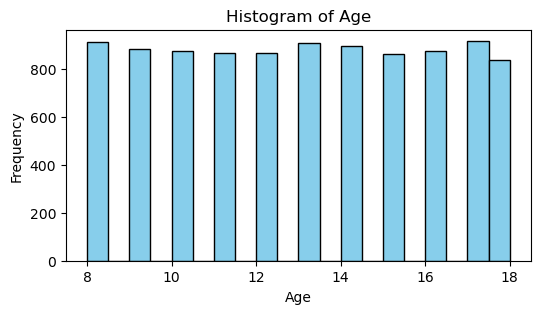

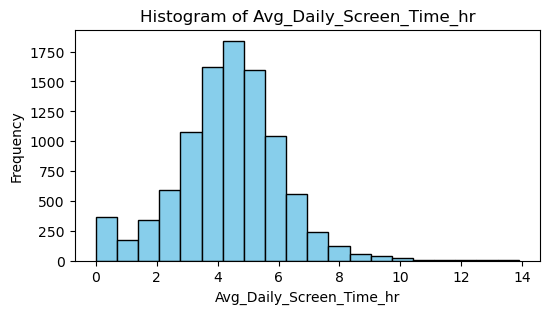

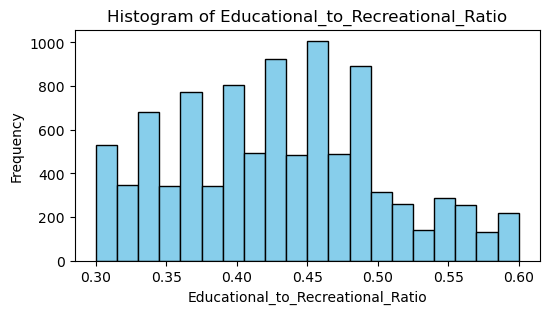


Correlation Matrix:
                                         Age  Avg_Daily_Screen_Time_hr  \
Age                                1.000000                  0.118328   
Avg_Daily_Screen_Time_hr           0.118328                  1.000000   
Educational_to_Recreational_Ratio -0.488617                 -0.087552   

                                   Educational_to_Recreational_Ratio  
Age                                                        -0.488617  
Avg_Daily_Screen_Time_hr                                   -0.087552  
Educational_to_Recreational_Ratio                           1.000000   



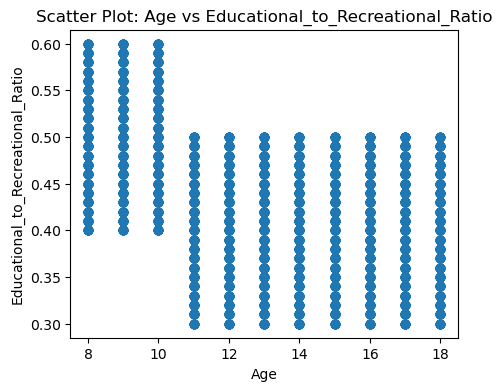

In [3]:
# ---------- TASK 1: Univariate & Bivariate Analysis ----------
print("=== TASK 1: Univariate & Bivariate Analysis ===")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNumeric Summary:\n", df[numeric_cols].describe())
print("\nCategorical Columns:", categorical_cols)

# Univariate plots
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    plt.hist(df[col].dropna(), bins=20, color="skyblue", edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Bivariate correlation
corr = df[numeric_cols].corr()
print("\nCorrelation Matrix:\n", corr, "\n")

# Scatter plot for top correlated pair
corr_abs = corr.abs().unstack().sort_values(ascending=False)
corr_abs = corr_abs[corr_abs < 1]
if not corr_abs.empty:
    top_pair = corr_abs.idxmax()
    plt.figure(figsize=(5,4))
    plt.scatter(df[top_pair[0]], df[top_pair[1]], alpha=0.6)
    plt.title(f"Scatter Plot: {top_pair[0]} vs {top_pair[1]}")
    plt.xlabel(top_pair[0])
    plt.ylabel(top_pair[1])
    plt.show()

=== TASK 2: Distribution Analysis ===


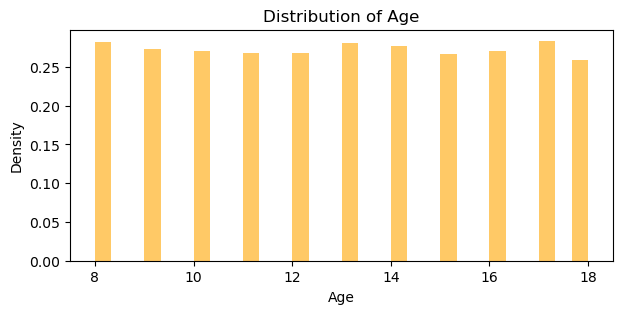

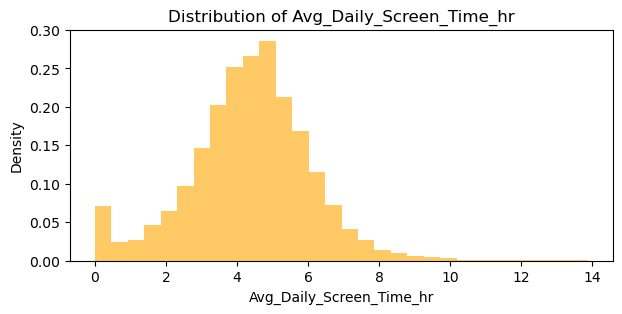

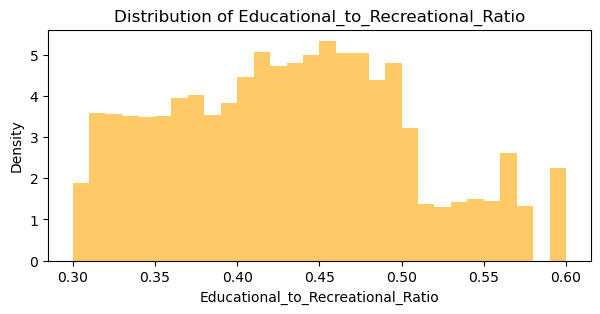

In [4]:
# ---------- TASK 2: Distribution Analysis ----------
print("=== TASK 2: Distribution Analysis ===")

for col in numeric_cols:
    s = df[col].dropna()
    plt.figure(figsize=(7,3))
    plt.hist(s, bins=30, density=True, alpha=0.6, color="orange")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()


=== TASK 3: Screen Time to Health Impact ===
   Age  ScreenHours Age_Group Health_Impact
0   14         3.99     13-18      Moderate
1   11         4.61      6-12          High
2   18         3.73     13-18      Moderate
3   15         1.21     13-18           Low
4   12         5.89      6-12     Very High 

Average Screen Hours by Age Group:
 Age_Group
0-2           NaN
3-5           NaN
6-12     4.161296
13-18    4.511955
19+           NaN
Name: ScreenHours, dtype: float64 

Health Impact Distribution:
 Health_Impact
High         4642
Moderate     2350
Very High    2079
Low           641
Name: count, dtype: int64 



C:\Users\HP\AppData\Local\Temp\ipykernel_7428\863011544.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_screen = df.groupby("Age_Group")["ScreenHours"].mean()


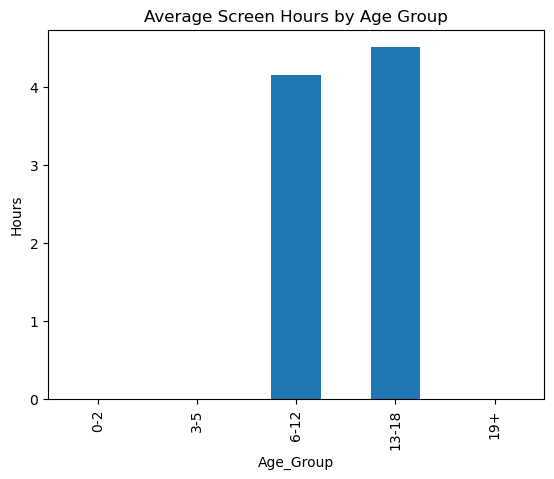

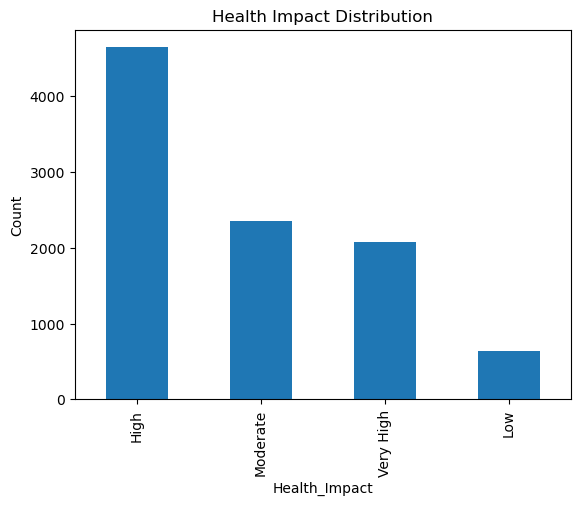

In [5]:
# ---------- TASK 3: Average Screen Time → Health Impact ----------
print("=== TASK 3: Screen Time to Health Impact ===")

df['Age'] = pd.to_numeric(df[age_col], errors='coerce')
df['ScreenHours'] = pd.to_numeric(df[screen_col], errors='coerce')

# Define age groups
bins = [-1, 2, 5, 12, 18, 150]
labels = ["0-2", "3-5", "6-12", "13-18", "19+"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

# Define thresholds for health impact
thresholds = {
    "0-2": [(0,0.5,"Low"), (0.5,1.5,"Moderate"), (1.5,3,"High"), (3,999,"Very High")],
    "3-5": [(0,1,"Low"), (1,2,"Moderate"), (2,3,"High"), (3,999,"Very High")],
    "6-12": [(0,1.5,"Low"), (1.5,3,"Moderate"), (3,5,"High"), (5,999,"Very High")],
    "13-18": [(0,2,"Low"), (2,4,"Moderate"), (4,6,"High"), (6,999,"Very High")],
    "19+": [(0,3,"Low"), (3,5,"Moderate"), (5,8,"High"), (8,999,"Very High")]
}

def map_health(age_group, hrs):
    if pd.isna(age_group) or pd.isna(hrs):
        return "Unknown"
    for lo, hi, label in thresholds.get(str(age_group), []):
        if lo <= hrs < hi:
            return label
    return "Unknown"

df["Health_Impact"] = df.apply(lambda r: map_health(r["Age_Group"], r["ScreenHours"]), axis=1)
print(df[["Age", "ScreenHours", "Age_Group", "Health_Impact"]].head(), "\n")

# Summary
avg_screen = df.groupby("Age_Group")["ScreenHours"].mean()
print("Average Screen Hours by Age Group:\n", avg_screen, "\n")

impact_counts = df["Health_Impact"].value_counts()
print("Health Impact Distribution:\n", impact_counts, "\n")

# Bar plot
avg_screen.plot(kind="bar", title="Average Screen Hours by Age Group")
plt.ylabel("Hours")
plt.show()

impact_counts.plot(kind="bar", title="Health Impact Distribution")
plt.ylabel("Count")
plt.show()

In [6]:
# ---------- TASK 4: Recommendation System ----------
print("=== TASK 4: Recommendation System ===")

def recommend(age, gender, screen_hours):
    # Determine age group
    if age <= 2: group = "0-2"
    elif age <= 5: group = "3-5"
    elif age <= 12: group = "6-12"
    elif age <= 18: group = "13-18"
    else: group = "19+"
    
    # Determine health impact
    impact = map_health(group, screen_hours)
    
    # Suggestion
    suggestions = {
        "Low": "Good balance! Maintain healthy screen habits.",
        "Moderate": "Slightly above limit — take regular breaks and reduce continuous use.",
        "High": "Too much screen time — reduce at least by 1-2 hours daily.",
        "Very High": "Severe screen exposure — strong reduction needed immediately."
    }
    
    # Final output
    return {
        "Age Group": group,
        "Gender": gender,
        "Screen Hours": screen_hours,
        "Health Impact": impact,
        "Recommendation": suggestions.get(impact, "Monitor screen usage and adjust daily limits.")
    }

# Example demo
print("Example Recommendations:\n")
examples = [
    (4, "Male", 2),
    (10, "Female", 4),
    (16, "Male", 5),
    (25, "Female", 7)
    # (25, "Female", 7)
]
for age, gender, hrs in examples:
    print(recommend(age, gender, hrs), "\n")


=== TASK 4: Recommendation System ===
Example Recommendations:

{'Age Group': '3-5', 'Gender': 'Male', 'Screen Hours': 2, 'Health Impact': 'High', 'Recommendation': 'Too much screen time — reduce at least by 1-2 hours daily.'} 

{'Age Group': '6-12', 'Gender': 'Female', 'Screen Hours': 4, 'Health Impact': 'High', 'Recommendation': 'Too much screen time — reduce at least by 1-2 hours daily.'} 

{'Age Group': '13-18', 'Gender': 'Male', 'Screen Hours': 5, 'Health Impact': 'High', 'Recommendation': 'Too much screen time — reduce at least by 1-2 hours daily.'} 

{'Age Group': '19+', 'Gender': 'Female', 'Screen Hours': 7, 'Health Impact': 'High', 'Recommendation': 'Too much screen time — reduce at least by 1-2 hours daily.'} 



In [7]:
 # Task 4 - Demo recommendation
    print("\n=== TASK 4: Recommendation System ===")
    try:
        user_input = input("Run interactive recommendation demo? (y/n) [n]: ").strip().lower() or "n"
        if user_input == "y":
            u_age = input("Enter age in years (e.g., 9): ").strip()
            u_gender = input("Enter gender (Male/Female/Other): ").strip()
            u_screen = input("Enter daily screen time in hours (e.g., 3.5): ").strip()
            rec = recommend(u_age, u_gender, float(u_screen), thresholds=thresholds)
            print("\n--- Recommendation ---")
            for k,v in rec.items():
                if isinstance(v, list):
                    print(f"{k}:")
                    for t in v:
                        print("  -", t)
                else:
                    print(f"{k}: {v}")
        else:
            # Example programmatic recommendations for each age group's median
            print("Skipping interactive demo. Writing example recommendations for median screen-hours per age-group.")
            med_by_group = mapped_df.groupby('age_group')['ScreenHours'].median().reset_index()
            recs = []
            for _, row in med_by_group.iterrows():
                ag = str(row['age_group'])
                med = 0.0 if pd.isna(row['ScreenHours']) else float(row['ScreenHours'])
                r = recommend( (2 if ag=="0-2" else (4 if ag=="3-5" else (9 if ag=="6-12" else (15 if ag=="13-18" else 25)))), "", med, thresholds=thresholds)
                r['age_group_label'] = ag
                r['median_screen_hours'] = med
                recs.append(r)
            rec_df = pd.DataFrame(recs)
            rec_df.to_csv(OUT_DIR / "example_recommendations_by_agegroup.csv", index=False)
            print("Saved example_recommendations_by_agegroup.csv")
    except Exception as e:
        print("Interactive demo skipped due to error:", e)

    print("\nAll tasks finished. Outputs are in:", OUT_DIR)
    print("Plots in:", PLOTS_DIR)

if __name__ == "__main__":
    main()

IndentationError: unexpected indent (4118351142.py, line 2)